# Vehicle Type Classification System using CNN and Transfer Learning

**Course:** Machine Learning  
**Project Phase:** Phase II - Proposal, Code Development, and Technical Implementation  
**Topic:** Vehicle Type Classification System  
**Field:** Transportation and Traffic Intelligence  
**Student:** Daniel Arias  

This notebook implements an image classification system using Convolutional Neural Networks (CNNs).  
The goal is to classify vehicle images from the Stanford Cars dataset and compare a custom CNN model with a transfer learning model.

In [1]:
# ============================================================
# 1. Import required libraries
# ============================================================

import os
import random
import shutil
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

2026-06-06 09:26:21.116026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780737981.327951      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780737981.380020      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780737981.838409      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780737981.838453      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780737981.838456      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# 2. Check Kaggle input files
# ============================================================

# Kaggle datasets are usually stored in /kaggle/input/
input_path = "/kaggle/input"

for dirname, _, filenames in os.walk(input_path):
    print(dirname)
    if len(filenames) > 0:
        print("Example files:", filenames[:5])
    print("-" * 60)

/kaggle/input
------------------------------------------------------------
/kaggle/input/datasets
------------------------------------------------------------
/kaggle/input/datasets/jutrera
------------------------------------------------------------
/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder
Example files: ['names.csv', 'anno_test.csv', 'anno_train.csv']
------------------------------------------------------------
/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data
------------------------------------------------------------
/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data/car_data
------------------------------------------------------------
/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data/car_data/test
------------------------------------------------------------
/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data/car_data/test/Dodge Ram Pickup 3

In [3]:
# ============================================================
# 3. Define dataset paths
# ============================================================

train_dir = "/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data/car_data/train"
test_dir = "/kaggle/input/datasets/jutrera/stanford-car-dataset-by-classes-folder/car_data/car_data/test"

print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

Train directory exists: True
Test directory exists: True
Number of classes: 196
First 10 classes: ['AM General Hummer SUV 2000', 'Acura Integra Type R 2001', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura ZDX Hatchback 2012', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012']


In [4]:
# ============================================================
# 4. Create folder for output figures and results
# ============================================================

output_dir = "/kaggle/working/outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output folder created:", output_dir)

Output folder created: /kaggle/working/outputs


In [5]:
# ============================================================
# 5. Explore dataset
# ============================================================

def count_images_per_class(directory):
    data = []

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            data.append([class_name, image_count])

    return pd.DataFrame(
        data,
        columns=["class_name", "image_count"]
    )

train_distribution = count_images_per_class(train_dir)
test_distribution = count_images_per_class(test_dir)

print("Training images:", train_distribution["image_count"].sum())
print("Testing images:", test_distribution["image_count"].sum())
print("Number of classes:", len(train_distribution))

train_distribution.head()

Training images: 8144
Testing images: 8041
Number of classes: 196


,class_name,image_count
0,AM General Hummer SUV 2000,45
1,Acura Integra Type R 2001,45
2,Acura RL Sedan 2012,32
3,Acura TL Sedan 2012,43
4,Acura TL Type-S 2008,42


In [6]:
# Dataset summary to later present as part of the data exploration process

dataset_summary = pd.DataFrame({
    "Metric": [
        "Training Images",
        "Testing Images",
        "Total Images",
        "Number of Classes"
    ],
    "Value": [
        train_distribution["image_count"].sum(),
        test_distribution["image_count"].sum(),
        train_distribution["image_count"].sum() + test_distribution["image_count"].sum(),
        len(train_distribution)
    ]
})

dataset_summary

,Metric,Value
0,Training Images,8144
1,Testing Images,8041
2,Total Images,16185
3,Number of Classes,196


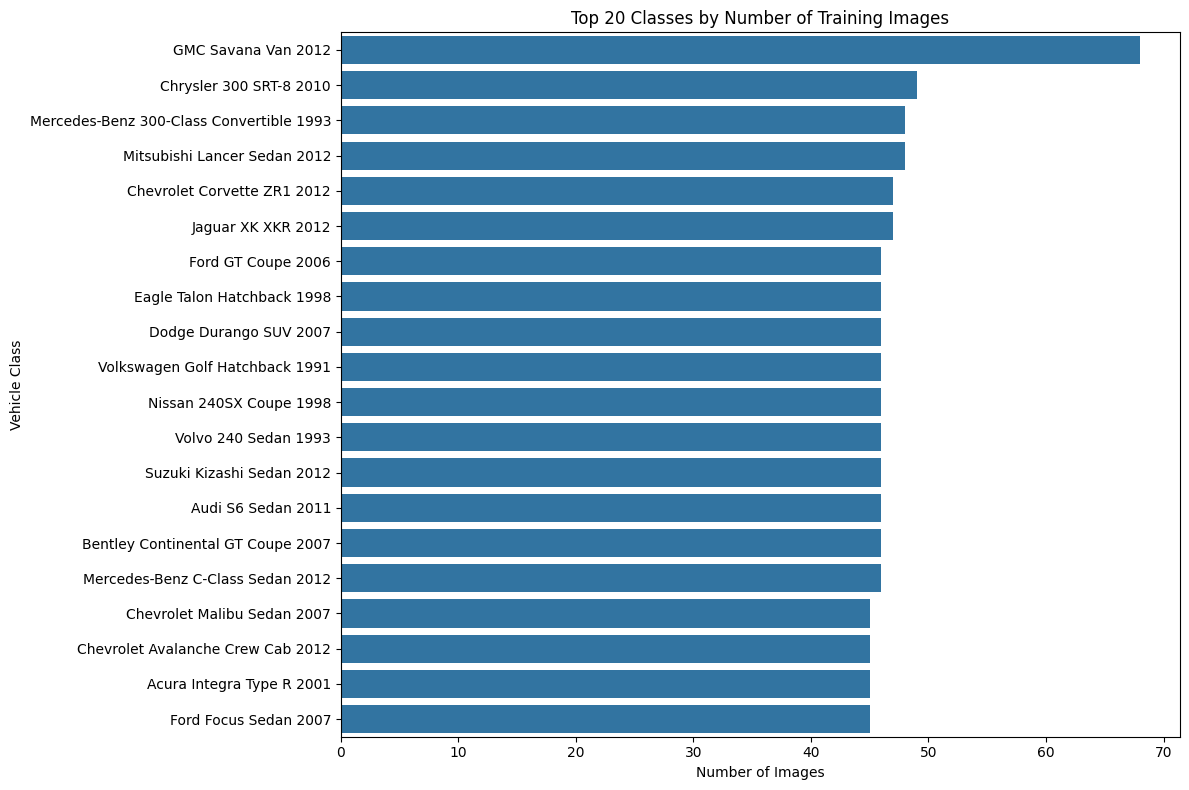

Saved: /kaggle/working/outputs/class_distribution_top20.png


In [7]:
# ============================================================
# 6. Visualize class distribution
# ============================================================

top20_classes = train_distribution.sort_values(by="image_count", ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top20_classes, x="image_count", y="class_name")
plt.title("Top 20 Classes by Number of Training Images")
plt.xlabel("Number of Images")
plt.ylabel("Vehicle Class")
plt.tight_layout()

class_distribution_path = os.path.join(output_dir, "class_distribution_top20.png")
plt.savefig(class_distribution_path, dpi=300)
plt.show()

print("Saved:", class_distribution_path)

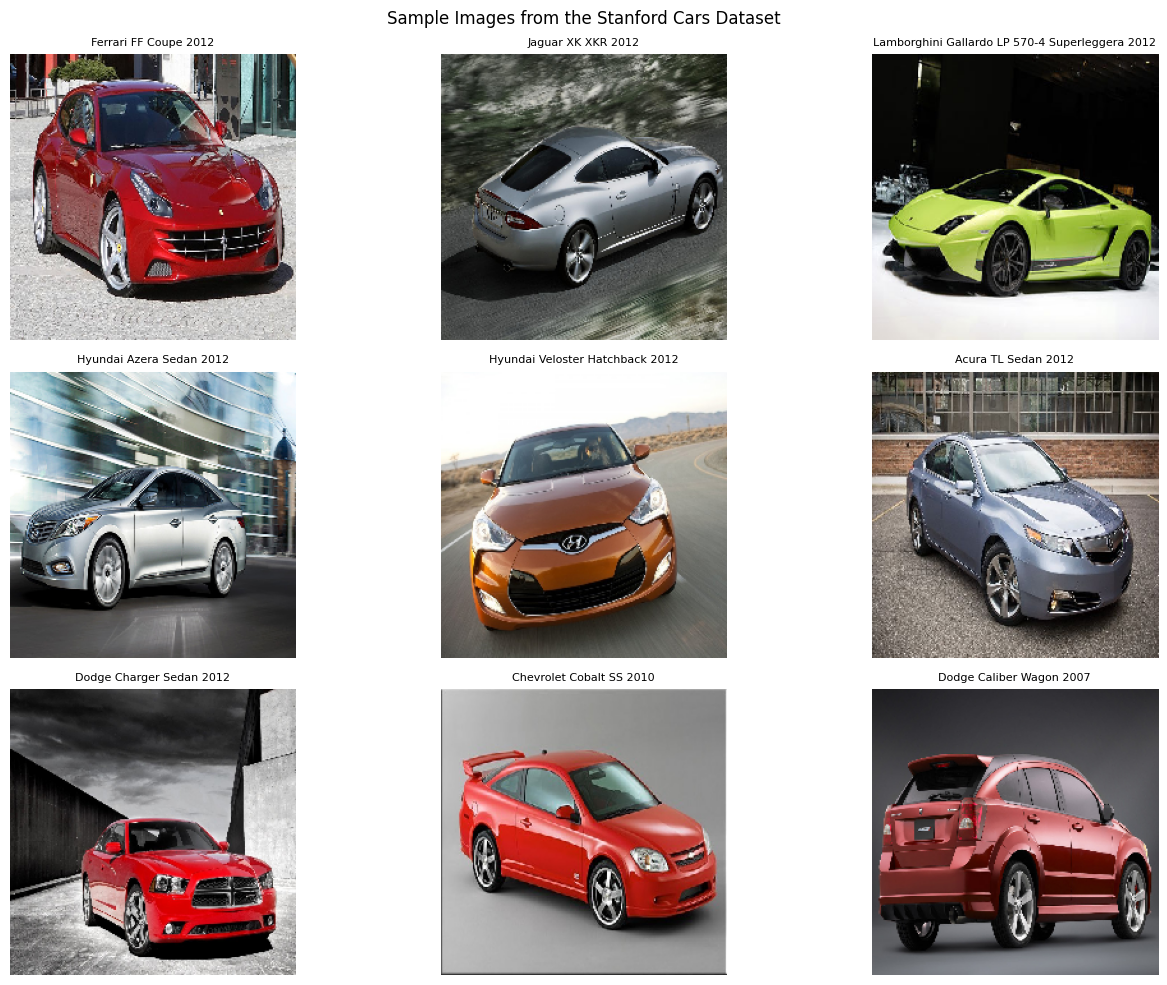

Saved: /kaggle/working/outputs/sample_vehicle_images.png


In [8]:
# ============================================================
# 7. Display sample images from random classes
# ============================================================

plt.figure(figsize=(14, 10))

sample_classes = random.sample(class_names, 9)

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = keras.utils.load_img(image_path, target_size=(224, 224))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Images from the Stanford Cars Dataset")
plt.tight_layout()

sample_images_path = os.path.join(output_dir, "sample_vehicle_images.png")
plt.savefig(sample_images_path, dpi=300)
plt.show()

print("Saved:", sample_images_path)

In [9]:
# ============================================================
# 8. Load images using TensorFlow image_dataset_from_directory
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Training dataset with validation split
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)

Found 8144 files belonging to 196 classes.
Using 6516 files for training.


I0000 00:00:1780739819.101960      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780739819.108480      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 8144 files belonging to 196 classes.
Using 1628 files for validation.
Found 8041 files belonging to 196 classes.
Number of classes: 196


In [11]:
# ============================================================
# 9. Improve dataset loading performance
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
# ============================================================
# 10. Data augmentation layer
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [14]:
# ============================================================
# 11. Custom CNN model
# ============================================================

custom_cnn = Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │        50,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,876,228 (37.67 MB)

 Trainable params: 9,876,228 (37.67 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ============================================================
# 12. Train custom CNN
# ============================================================

EPOCHS_CUSTOM = 10

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

custom_history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CUSTOM,
    callbacks=[early_stopping]
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.0198 - loss: 5.1267 - val_accuracy: 0.0233 - val_loss: 5.1372
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.0224 - loss: 5.0850 - val_accuracy: 0.0227 - val_loss: 5.1070
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.0276 - loss: 5.0569 - val_accuracy: 0.0227 - val_loss: 5.0861
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.0315 - loss: 5.0269 - val_accuracy: 0.0264 - val_loss: 5.0752
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.0347 - loss: 4.9833 - val_accuracy: 0.0270 - val_loss: 5.0496
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.0411 - loss: 4.9362 - val_accuracy: 0.0326 - val_loss: 5.0184
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.0393 - loss: 4.8975 - val_accuracy: 0.0307 - val_loss: 4.9971
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.0486 - loss: 4.8569 - 

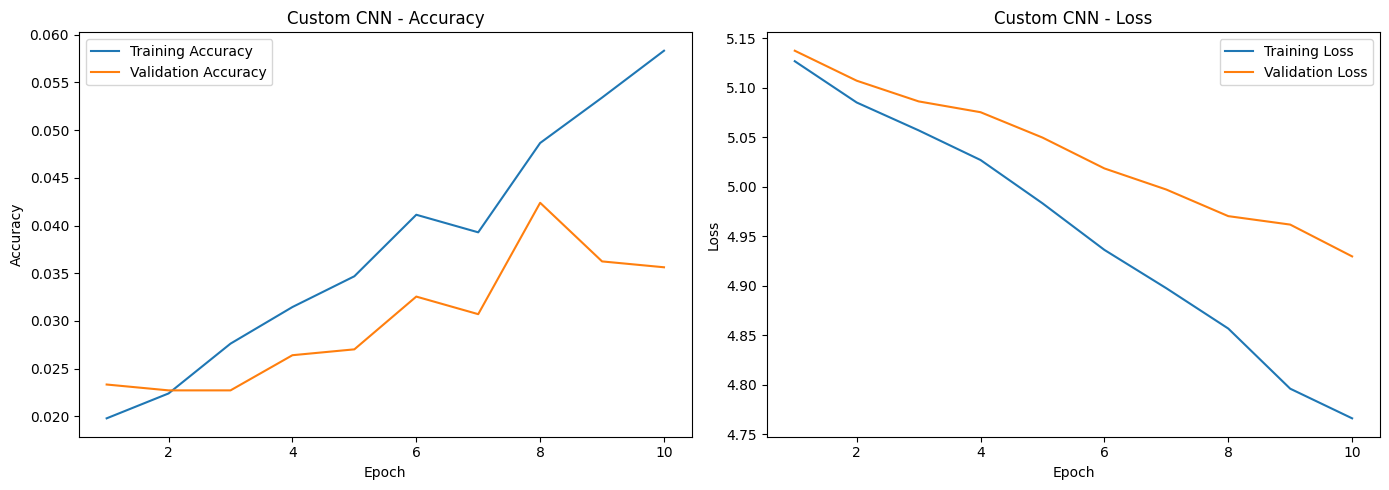

Saved: /kaggle/working/outputs/custom_cnn_accuracy_loss_curves.png


In [17]:
# ============================================================
# 13. Plot accuracy and loss curves for custom CNN
# ============================================================

def plot_training_curves(history, model_name, save_path):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

custom_curves_path = os.path.join(output_dir, "custom_cnn_accuracy_loss_curves.png")
plot_training_curves(custom_history, "Custom CNN", custom_curves_path)

print("Saved:", custom_curves_path)

In [18]:
# ============================================================
# 14. Evaluate custom CNN on test set
# ============================================================

custom_test_loss, custom_test_accuracy = custom_cnn.evaluate(test_ds)

print("Custom CNN Test Loss:", custom_test_loss)
print("Custom CNN Test Accuracy:", custom_test_accuracy)

252/252 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.0446 - loss: 4.9004
Custom CNN Test Loss: 4.900363922119141
Custom CNN Test Accuracy: 0.044646188616752625


In [20]:
# ============================================================
# 15. Transfer learning model using MobileNetV2
# ============================================================

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model first
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

mobilenet_model = keras.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196)            │       251,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,509,060 (9.57 MB)

 Trainable params: 251,076 (980.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
# ============================================================
# 16. Train MobileNetV2 transfer learning model
# ============================================================

EPOCHS_TRANSFER = 10

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=[early_stopping]
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.0061 - loss: 5.6098 - val_accuracy: 0.0178 - val_loss: 5.1561
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.0157 - loss: 5.2463 - val_accuracy: 0.0326 - val_loss: 4.9344
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.0266 - loss: 4.9977 - val_accuracy: 0.0577 - val_loss: 4.7563
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.0439 - loss: 4.7859 - val_accuracy: 0.0756 - val_loss: 4.6048
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.0658 - loss: 4.6160 - val_accuracy: 0.0940 - val_loss: 4.4763
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.0800 - loss: 4.4774 - val_accuracy: 0.1044 - val_loss: 4.3582
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.1005 - loss: 4.3372 - val_accuracy: 0.1229 - val_loss: 4.2560
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.1143 - loss: 4.2077 - 

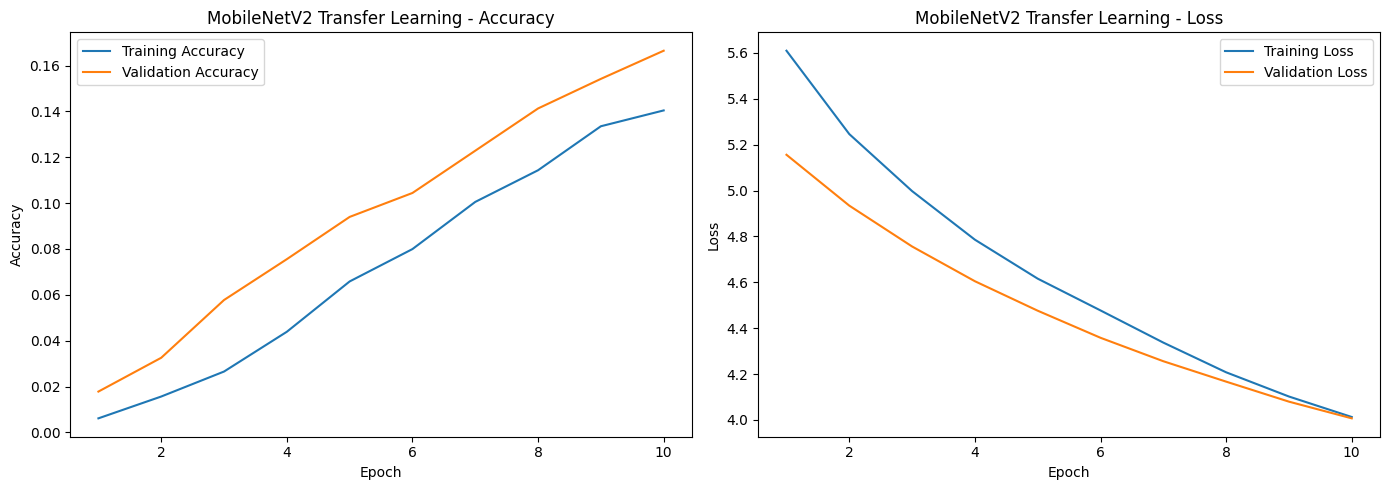

Saved: /kaggle/working/outputs/mobilenetv2_accuracy_loss_curves.png


In [22]:
# ============================================================
# 17. Plot accuracy and loss curves for MobileNetV2
# ============================================================

mobilenet_curves_path = os.path.join(output_dir, "mobilenetv2_accuracy_loss_curves.png")
plot_training_curves(mobilenet_history, "MobileNetV2 Transfer Learning", mobilenet_curves_path)

print("Saved:", mobilenet_curves_path)

In [23]:
# ============================================================
# 18. Evaluate MobileNetV2 on test set
# ============================================================

mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

252/252 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.1750 - loss: 3.9789
MobileNetV2 Test Loss: 3.978870391845703
MobileNetV2 Test Accuracy: 0.17497824132442474


In [24]:
# ============================================================
# 19. Compare custom CNN and MobileNetV2
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2 Transfer Learning"],
    "Test Loss": [custom_test_loss, mobilenet_test_loss],
    "Test Accuracy": [custom_test_accuracy, mobilenet_test_accuracy]
})

comparison_df

,Model,Test Loss,Test Accuracy
0,Custom CNN,4.900364,0.044646
1,MobileNetV2 Transfer Learning,3.978870,0.174978


In [25]:
# Save comparison table
comparison_path = os.path.join(output_dir, "model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

Saved: /kaggle/working/outputs/model_comparison.csv


In [26]:
# ============================================================
# 20. Select best model based on test accuracy
# ============================================================

if mobilenet_test_accuracy >= custom_test_accuracy:
    best_model = mobilenet_model
    best_model_name = "MobileNetV2 Transfer Learning"
else:
    best_model = custom_cnn
    best_model_name = "Custom CNN"

print("Best model:", best_model_name)

Best model: MobileNetV2 Transfer Learning


In [27]:
# ============================================================
# 21. Generate predictions on test set
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed.")

Predictions completed.


In [28]:
# ============================================================
# 22. Classification report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

classification_report_path = os.path.join(output_dir, "classification_report.txt")

with open(classification_report_path, "w") as f:
    f.write(f"Best Model: {best_model_name}\n\n")
    f.write(report)

print("Saved:", classification_report_path)

                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.71      0.84      0.77        44
                             Acura Integra Type R 2001       0.15      0.25      0.19        44
                                   Acura RL Sedan 2012       0.00      0.00      0.00        32
                                   Acura TL Sedan 2012       0.07      0.02      0.03        43
                                  Acura TL Type-S 2008       0.03      0.02      0.03        42
                                  Acura TSX Sedan 2012       0.00      0.00      0.00        40
                              Acura ZDX Hatchback 2012       0.00      0.00      0.00        39
              Aston Martin V8 Vantage Convertible 2012       0.25      0.16      0.19        45
                    Aston Martin V8 Vantage Coupe 2012       0.11      0.22      0.15        41
                  Aston Martin Virage C

In [29]:
# ============================================================
# 23. Confusion matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

# Save full confusion matrix as CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv_path = os.path.join(output_dir, "full_confusion_matrix.csv")
cm_df.to_csv(cm_csv_path)

print("Saved full confusion matrix:", cm_csv_path)

Saved full confusion matrix: /kaggle/working/outputs/full_confusion_matrix.csv


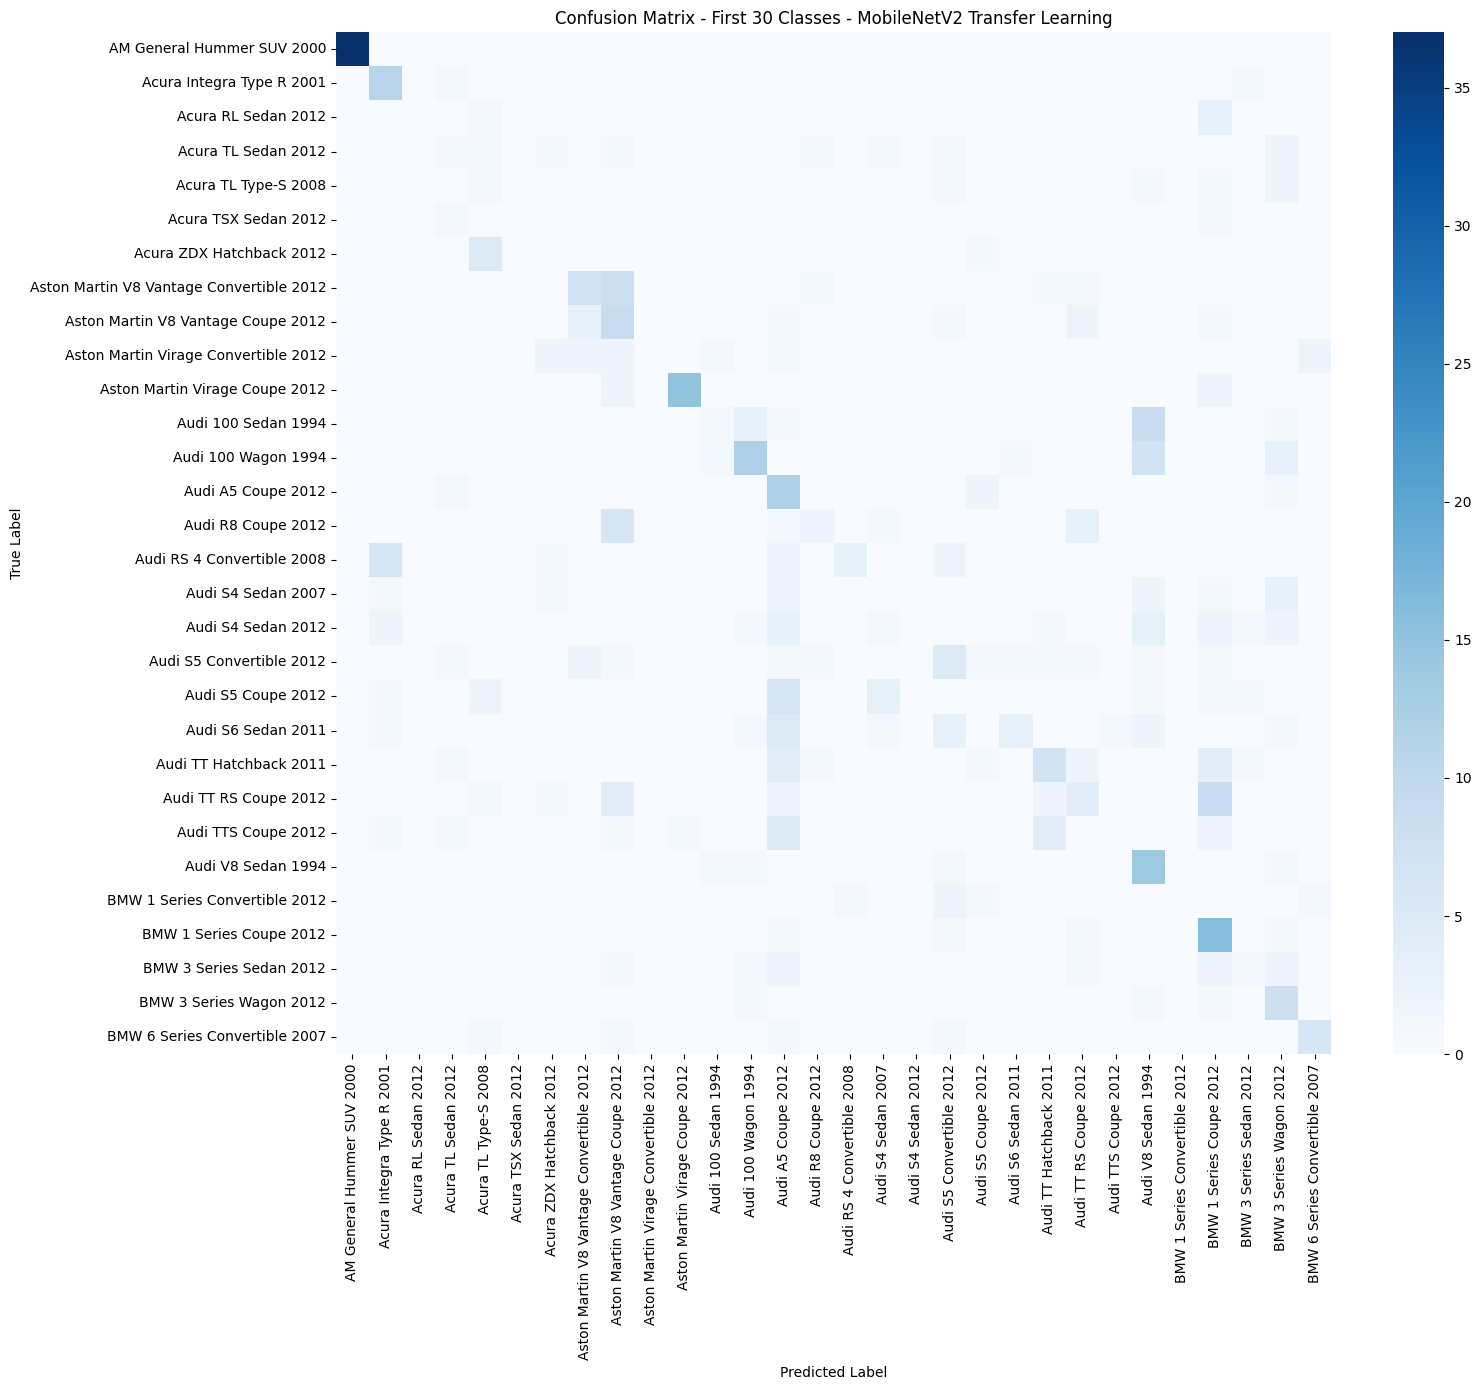

Saved: /kaggle/working/outputs/confusion_matrix_first30_classes.png


In [30]:
# Plot only first 30 classes for readability
num_display_classes = 30

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm[:num_display_classes, :num_display_classes],
    annot=False,
    cmap="Blues",
    xticklabels=class_names[:num_display_classes],
    yticklabels=class_names[:num_display_classes]
)

plt.title(f"Confusion Matrix - First {num_display_classes} Classes - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

confusion_matrix_path = os.path.join(output_dir, "confusion_matrix_first30_classes.png")
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Saved:", confusion_matrix_path)

Found 8041 files belonging to 196 classes.


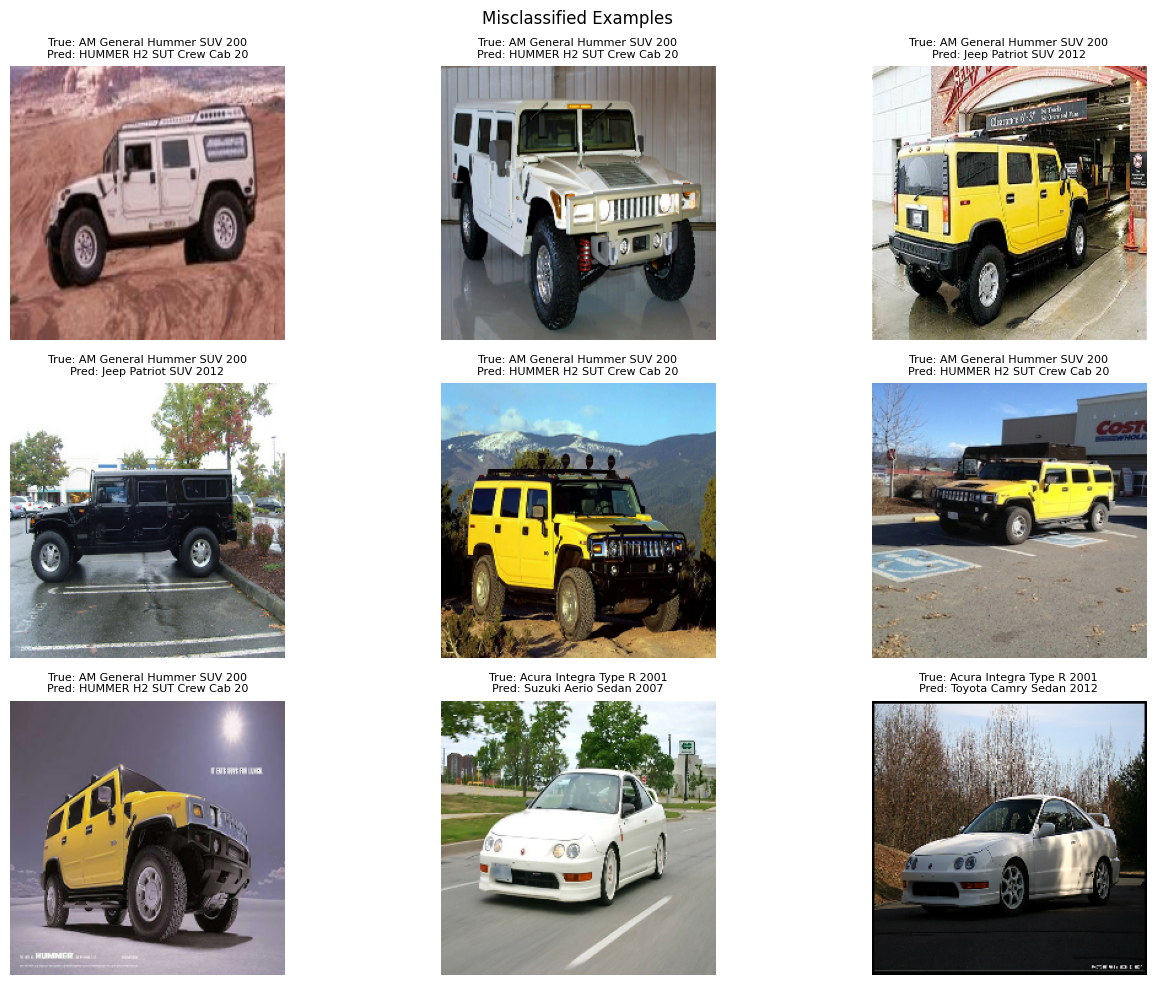

Saved: /kaggle/working/outputs/misclassified_examples.png


In [31]:
# ============================================================
# 24. Error analysis: show misclassified examples
# ============================================================

# Reload test dataset without cache/prefetch for easier image visualization
test_ds_vis = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=1,
    label_mode="categorical",
    shuffle=False
)

misclassified_images = []

for image, label in test_ds_vis:
    prediction = best_model.predict(image, verbose=0)
    
    true_label = np.argmax(label.numpy(), axis=1)[0]
    predicted_label = np.argmax(prediction, axis=1)[0]
    
    if true_label != predicted_label:
        misclassified_images.append((image[0].numpy().astype("uint8"), true_label, predicted_label))
    
    if len(misclassified_images) >= 9:
        break

plt.figure(figsize=(14, 10))

for i, (img, true_label, predicted_label) in enumerate(misclassified_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {class_names[true_label][:25]}\nPred: {class_names[predicted_label][:25]}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Misclassified Examples")
plt.tight_layout()

error_analysis_path = os.path.join(output_dir, "misclassified_examples.png")
plt.savefig(error_analysis_path, dpi=300)
plt.show()

print("Saved:", error_analysis_path)

In [32]:
# ============================================================
# 25. Save trained models
# ============================================================

custom_model_path = os.path.join(output_dir, "custom_cnn_model.keras")
mobilenet_model_path = os.path.join(output_dir, "mobilenetv2_model.keras")

custom_cnn.save(custom_model_path)
mobilenet_model.save(mobilenet_model_path)

print("Saved custom CNN model:", custom_model_path)
print("Saved MobileNetV2 model:", mobilenet_model_path)

Saved custom CNN model: /kaggle/working/outputs/custom_cnn_model.keras
Saved MobileNetV2 model: /kaggle/working/outputs/mobilenetv2_model.keras


In [36]:
# ============================================================
# 26. Final project summary
# ============================================================

print("PROJECT SUMMARY")
print("=" * 60)
print("Project title: Vehicle Type Classification System using CNN and Transfer Learning")
print("Dataset: Stanford Cars Dataset by Classes Folder")
print("Number of classes:", num_classes)
print("Image size:", IMG_SIZE)
print()
print("Custom CNN Test Accuracy:", round(custom_test_accuracy, 4))
print("MobileNetV2 Test Accuracy:", round(mobilenet_test_accuracy, 4))
print("Best model:", best_model_name)
print()
print("Saved outputs are available in:", output_dir)

PROJECT SUMMARY
Project title: Vehicle Type Classification System using CNN and Transfer Learning
Dataset: Stanford Cars Dataset by Classes Folder
Number of classes: 196
Image size: (224, 224)

Custom CNN Test Accuracy: 0.0446
MobileNetV2 Test Accuracy: 0.175
Best model: MobileNetV2 Transfer Learning

Saved outputs are available in: /kaggle/working/outputs
